# GPT-2 IOI — full hidden-dimension attribution patching

We look at **every hidden dimension across the whole network** for the IOI task,
rather than a hand-picked set of MLP neurons / attention heads / the residual stream.
Attribution patching gives us a causal score for *all* activations from a single
backward pass, so we can draw a map of the entire network.

- **Model:** GPT-2 small — **Task:** Indirect Object Identification (IOI)
- **Data:** [`mib-bench/ioi`](https://huggingface.co/datasets/mib-bench/ioi)
- **Paper:** `../paper/IOI_interpretability_in_the_wild_2211.00593.pdf` (arXiv:2211.00593)

In [1]:
import os, sys, json
sys.path.insert(0, os.path.abspath('..'))
import torch
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from IPython.display import Image, display
from src import data, attribution, storage, viz

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE, '|', torch.cuda.get_device_name(0) if DEVICE=='cuda' else '')
FIGS = os.path.abspath('../results/figures'); os.makedirs(FIGS, exist_ok=True)

device: cuda | NVIDIA GeForce RTX 4050 Laptop GPU


## 1. Load GPT-2 and build clean / corrupt IOI batches

Each IOI example has a clean prompt and several counterfactuals. We use the
**ABC counterfactual** as the corruption: the repeated subject is replaced by a
third name (`Henry gave → Angel gave`), which breaks the IOI mechanism. The
metric is the indirect-object logit difference `logit(IO) − logit(S)`.

In [2]:
model = GPT2LMHeadModel.from_pretrained('openai-community/gpt2').to(DEVICE).eval()
tok = GPT2TokenizerFast.from_pretrained('openai-community/gpt2')
n_layers = model.config.n_layer

raw = data.load_raw('test')
ex = raw[0]
print('CLEAN  :', ex['prompt'])
print('CORRUPT:', ex['abc_counterfactual']['prompt'])
print('choices: [IO, S] =', ex['choices'], '-> answer =', ex['choices'][ex['answerKey']])

batches = data.build_batches(tok, raw, n=64, batch_size=16, corruption='abc_counterfactual', device=DEVICE)
print('batches:', len(batches), '| examples:', sum(b.clean_ids.shape[0] for b in batches),
      '| lengths:', sorted({b.seq_len for b in batches}))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

CLEAN  : Then, Henry and Phil had a lot of fun at the harbor. Henry gave a basket to
CORRUPT: Then, Henry and Phil had a lot of fun at the harbor. Angel gave a basket to
choices: [IO, S] = ['Phil', 'Henry'] -> answer = Phil
batches: 10 | examples: 64 | lengths: [11, 12, 14, 15, 16, 17, 18, 19, 20, 21]


## 2. (Optional) Inspect activations with nnsight

nnsight makes reading the full hidden state anywhere in the network trivial. We
use it for inspection; the attribution engine uses PyTorch hooks for gradients
(see `../docs/NNSIGHT_NOTES.md` for the 0.7.0 gradient caveat).

In [3]:
try:
    from src import nnsight_inspect
    nn_model = nnsight_inspect.load('openai-community/gpt2', DEVICE)
    acts = nnsight_inspect.capture_all_sites(nn_model, ex['prompt'])
    print('nnsight captured', len(acts), 'sites; e.g.')
    for k in ['L09.resid_post', 'L09.mlp_hidden']:
        print(' ', k, tuple(acts[k].shape))
except Exception as e:
    print('nnsight inspection skipped:', type(e).__name__, e)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

nnsight captured 48 sites; e.g.
  L09.resid_post (19, 768)
  L09.mlp_hidden (1, 19, 3072)


## 3. Attribution patching across all hidden dims

Denoising direction: `attr = (a_clean − a_corrupt) · grad_corrupt(metric)`.
Cost is 1 clean forward + 1 corrupt forward + 1 corrupt backward per batch —
the per-element results are reduced on the fly into compact summaries.

In [4]:
result, meta = attribution.run_attribution(model, batches, pos_k=8)
print('clean   logit diff:', round(meta['mean_clean_logit_diff'], 3))
print('corrupt logit diff:', round(meta['mean_corrupt_logit_diff'], 3))
manifest = storage.save(result, meta, os.path.abspath('../results'))
print('hidden dims tracked:', f"{manifest['total_hidden_dims_tracked']:,}",
      '| per_dim.npz:', round(manifest['storage_bytes']['per_dim_npz']/1e6, 3), 'MB')

  batch 1/10 (L=19, b=8) clean_ld=+3.757 corrupt_ld=-0.553
  batch 2/10 (L=14, b=5) clean_ld=+2.950 corrupt_ld=-0.281


  batch 3/10 (L=16, b=12) clean_ld=+2.957 corrupt_ld=-0.589
  batch 4/10 (L=18, b=12) clean_ld=+2.834 corrupt_ld=-0.777


  batch 5/10 (L=11, b=5) clean_ld=+2.497 corrupt_ld=+0.299
  batch 6/10 (L=15, b=12) clean_ld=+2.871 corrupt_ld=-0.503


  batch 7/10 (L=17, b=5) clean_ld=+4.120 corrupt_ld=-0.222
  batch 8/10 (L=20, b=3) clean_ld=+3.794 corrupt_ld=-0.165


  batch 9/10 (L=12, b=1) clean_ld=+3.072 corrupt_ld=+0.146
  batch 10/10 (L=21, b=1) clean_ld=+1.519 corrupt_ld=-1.124
clean   logit diff: 3.037
corrupt logit diff: -0.377
hidden dims tracked: 73,728 | per_dim.npz: 0.29 MB


## 4. The full-network map

Layer × component. This should rediscover the IOI circuit: residual stream
ramping to L9–L11 (name movers), and `attn_out` flipping negative late
(negative name movers / S-inhibition).

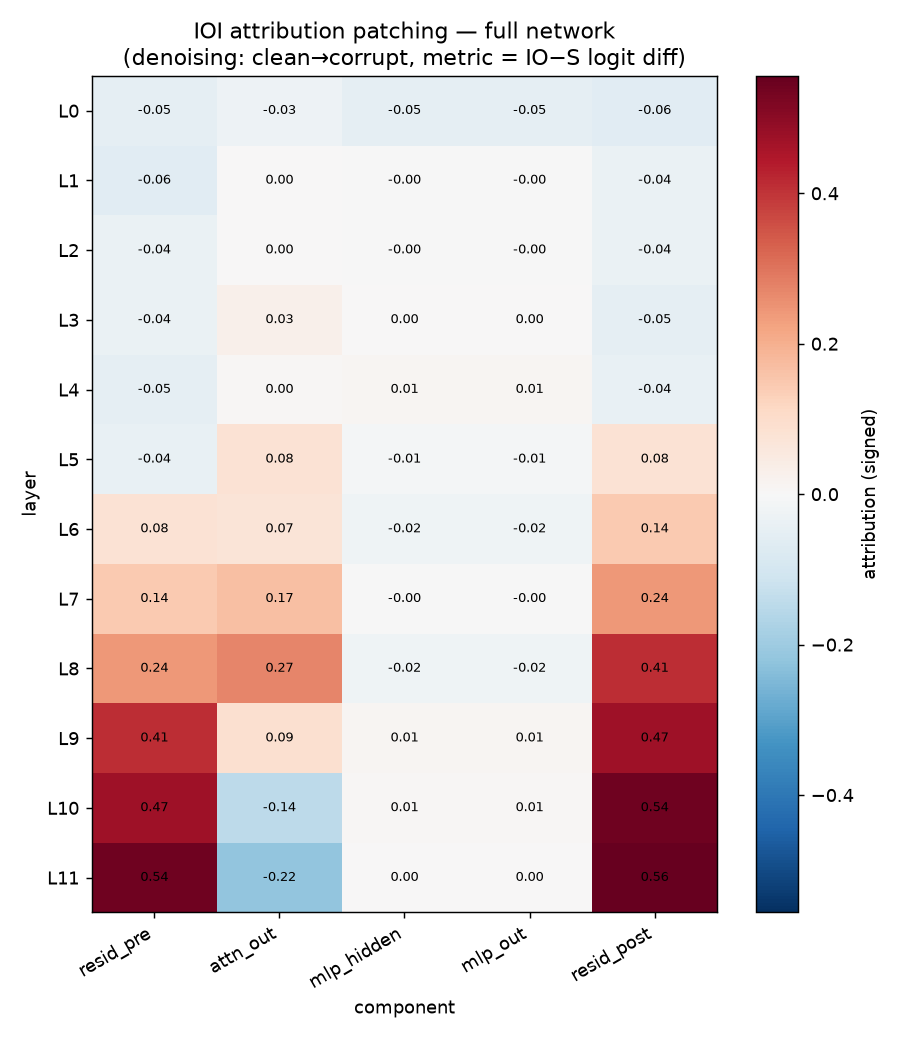

In [5]:
viz.network_heatmap(result, n_layers, f'{FIGS}/network_signed.png', signed=True)
display(Image(f'{FIGS}/network_signed.png'))

## 5. Every hidden dimension

Per-component layer × hidden-dim heatmaps. The structure here is sparse and is
exactly what gets averaged away when you aggregate into heads or neurons.

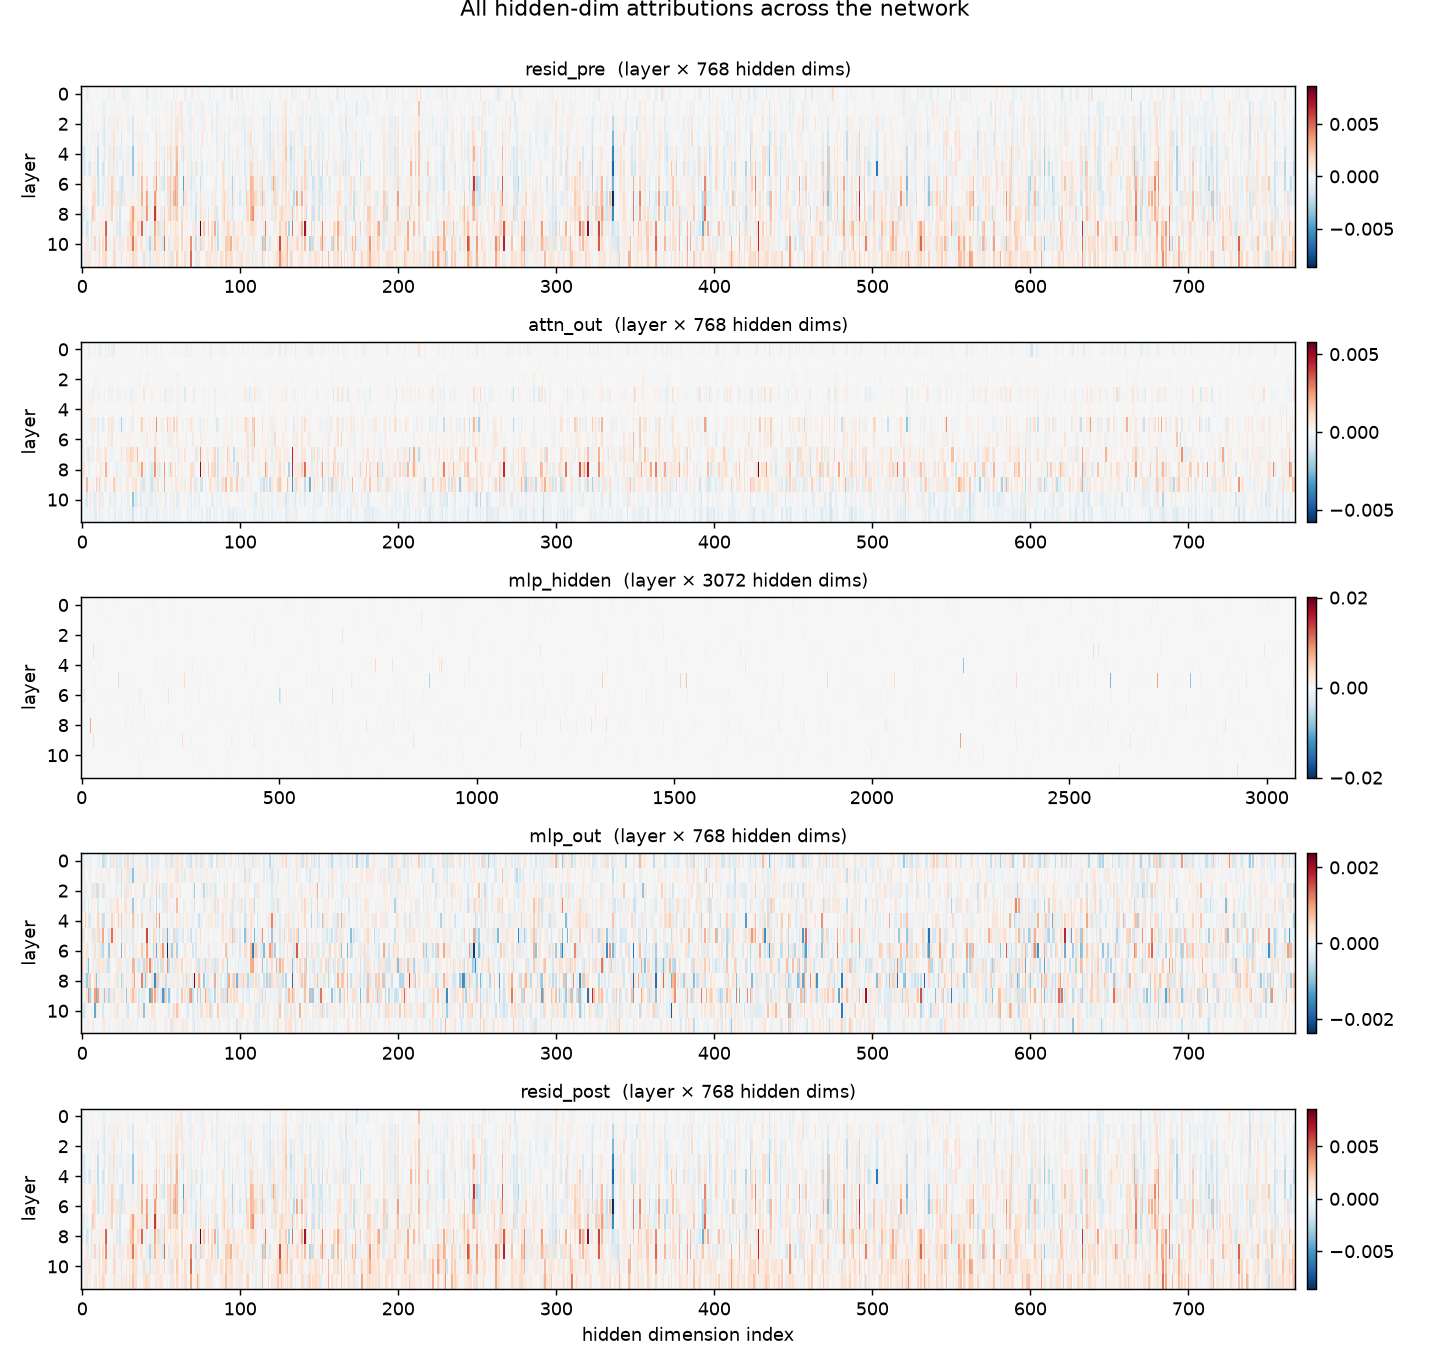

In [6]:
viz.hidden_dim_heatmaps(result, n_layers, f'{FIGS}/hidden_dims.png')
display(Image(f'{FIGS}/hidden_dims.png'))

## 6. Top units and where the signal lives

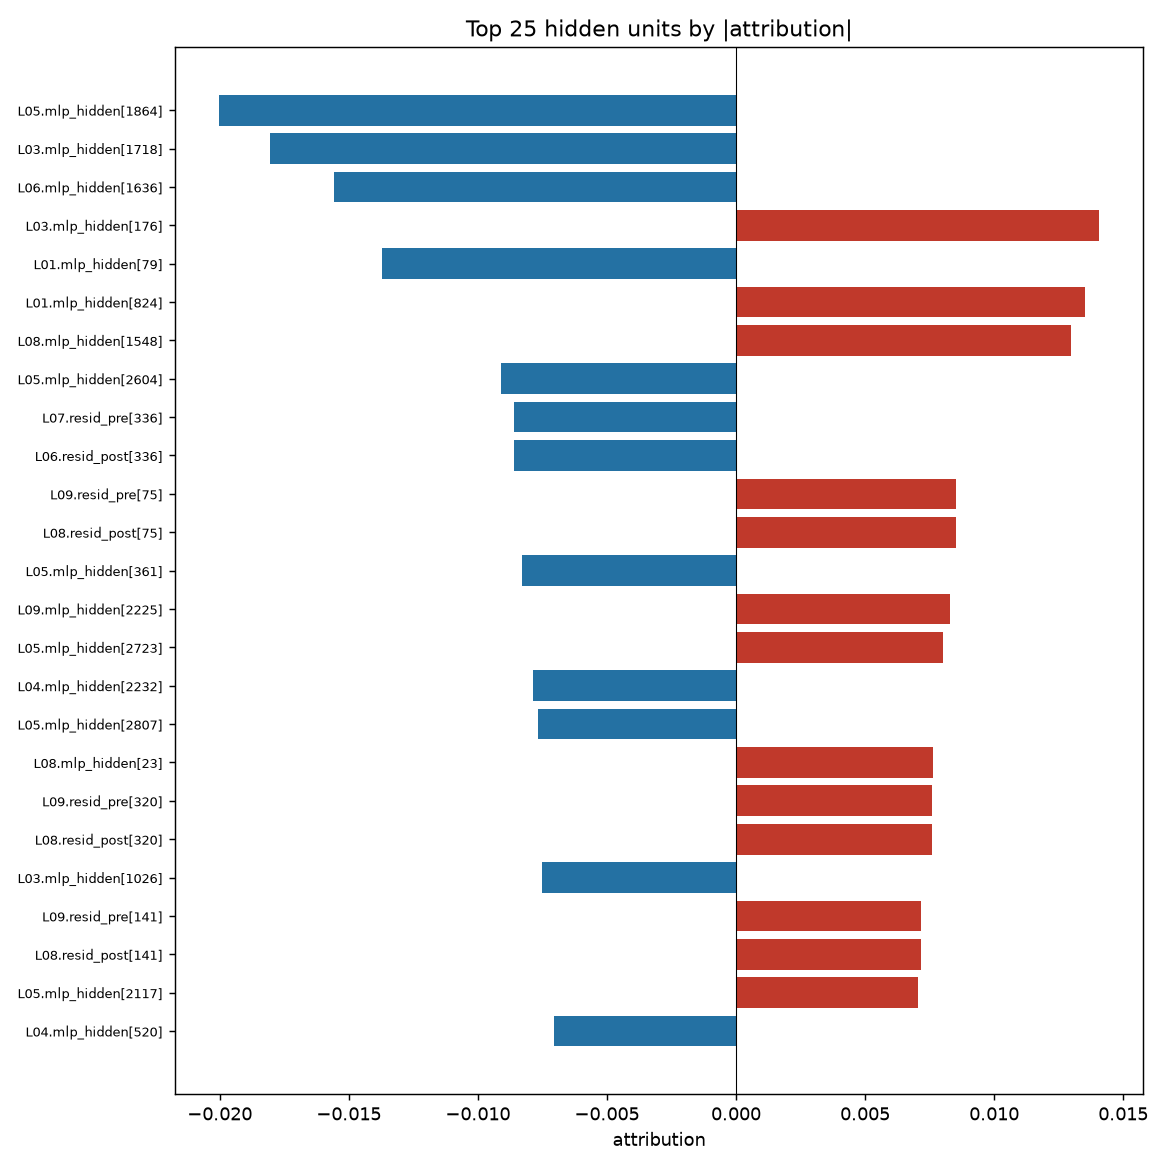

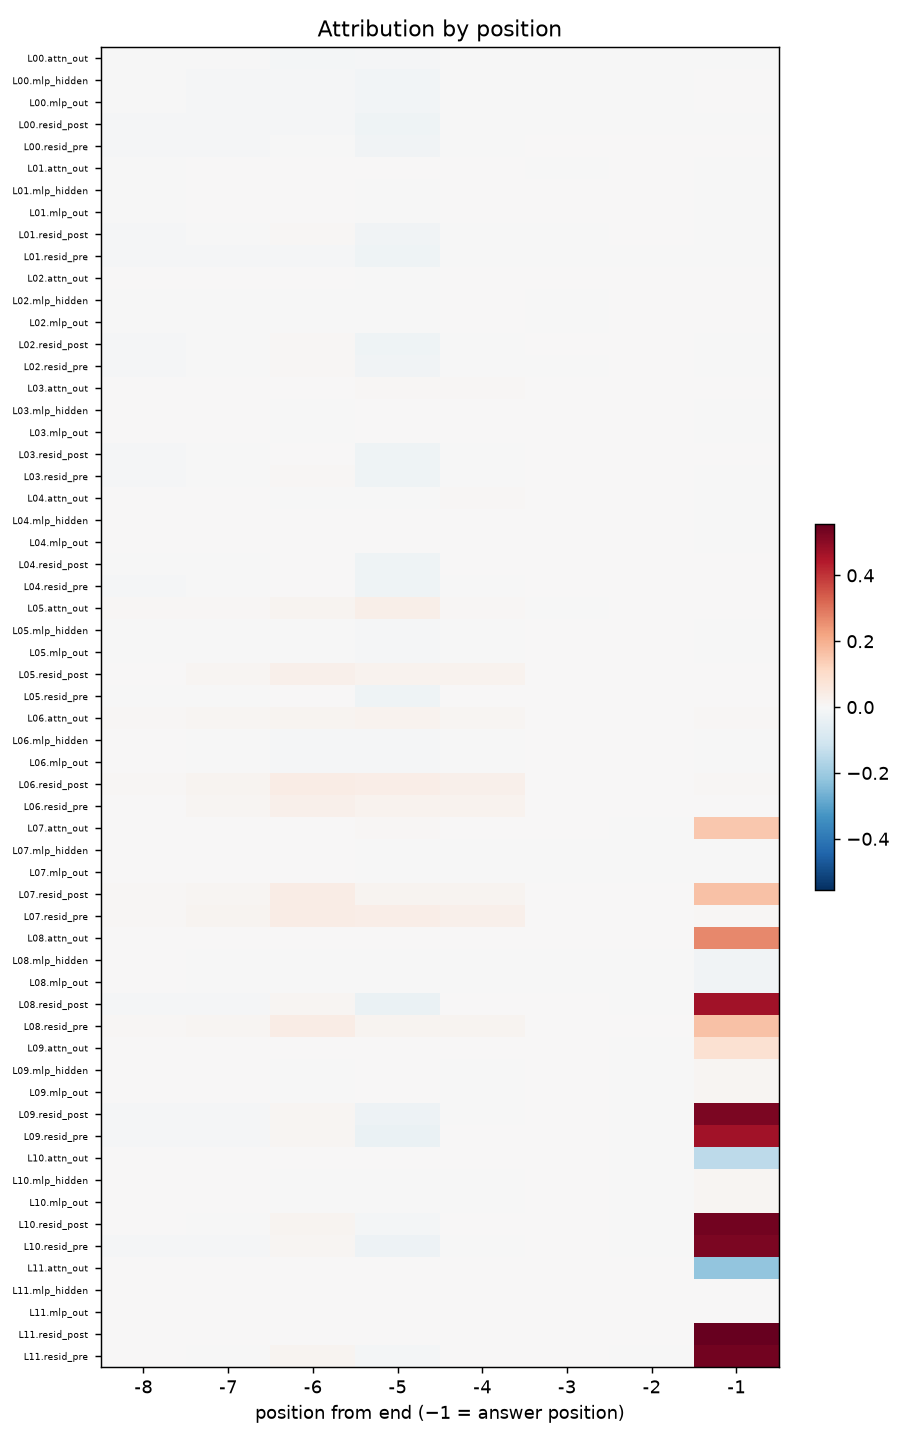

top sites by |attribution|:
  L09.resid_post   |attr|=  2.671 signed= +0.471
  L10.resid_pre    |attr|=  2.671 signed= +0.471
  L08.resid_post   |attr|=  2.259 signed= +0.410
  L09.resid_pre    |attr|=  2.259 signed= +0.410
  L10.resid_post   |attr|=  2.236 signed= +0.542
  L11.resid_pre    |attr|=  2.236 signed= +0.542
  L07.resid_post   |attr|=  2.173 signed= +0.242
  L08.resid_pre    |attr|=  2.173 signed= +0.242


In [7]:
top, _ = viz.top_units(result, 25, f'{FIGS}/top_units.png')
viz.position_heatmap(result, n_layers, f'{FIGS}/positions.png')
display(Image(f'{FIGS}/top_units.png'))
display(Image(f'{FIGS}/positions.png'))
print('top sites by |attribution|:')
for s, v in sorted(result.scalar_abs.items(), key=lambda kv: -kv[1])[:8]:
    print(f'  {s:16s} |attr|={v:7.3f} signed={result.scalar_signed[s]:+7.3f}')

# Part 2 — Tracing the head-level circuit

The component map above is at the granularity of whole sub-layers. To trace the
paper's **head-level** circuit we attribute per attention head (via the `c_proj`
input `z`) and per token position. This recovers the canonical circuit and lets
us draw it annotated with our own numbers.

In [8]:
from src import heads, analysis, headviz, circuitdiagram
res = heads.run_head_attribution(model, batches, progress=lambda *_: None)
rep = analysis.report(res, top_k=26)
cov = rep['coverage']
print(f"circuit recovery: {cov['n_recovered_in_top_k']}/{cov['n_circuit']} circuit heads in top-26")
print("missed:", [h['head'] for h in cov['heads'] if not h['in_top_k']])
print("extra (non-circuit) heads in top-26:", [e['head'] for e in rep['extras_in_top_k']])

circuit recovery: 19/26 circuit heads in top-26
missed: ['0.1', '0.10', '2.2', '4.11', '9.0', '10.2', '11.9']
extra (non-circuit) heads in top-26: ['9.4', '6.0', '11.6', '9.3', '8.3', '4.3', '6.6']


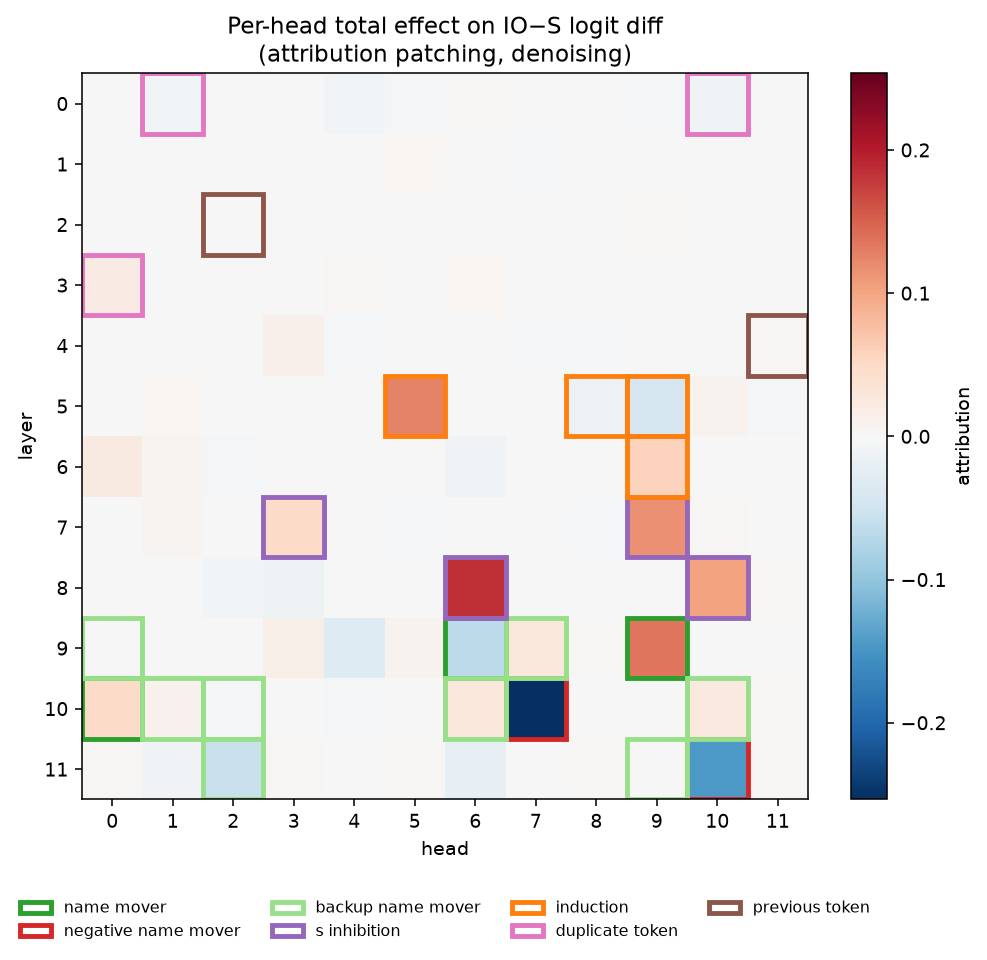

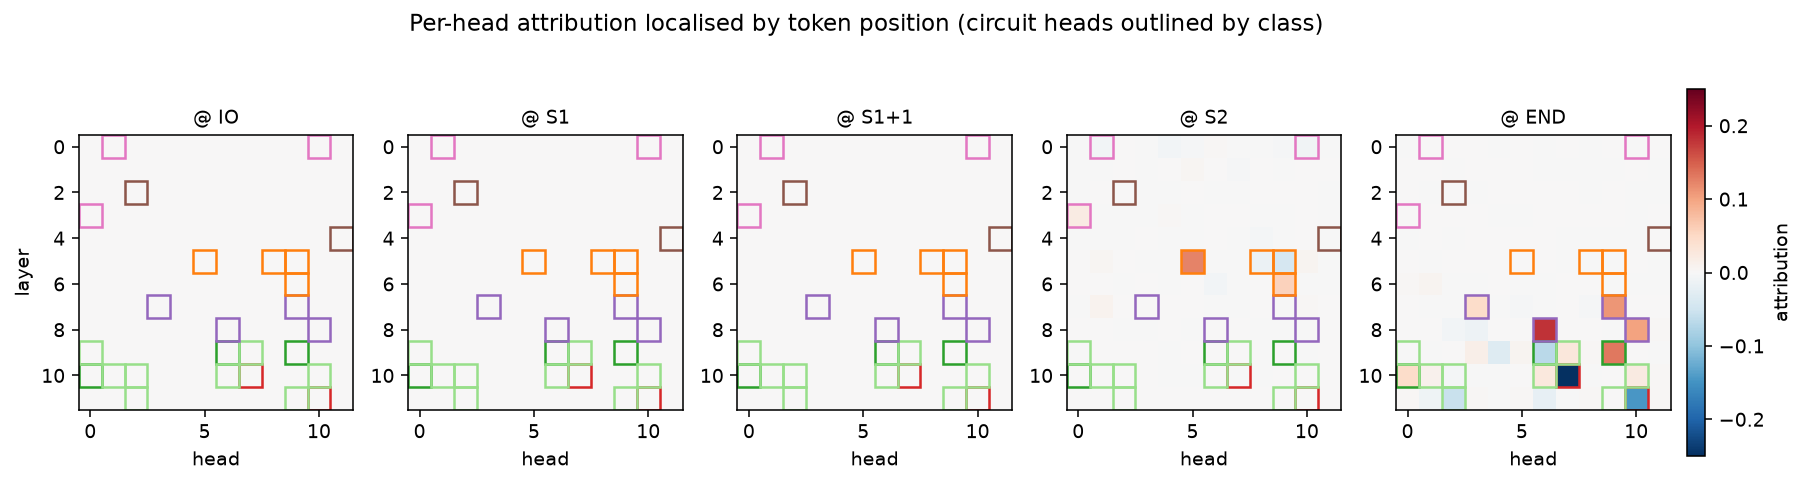

In [9]:
headviz.head_heatmap(res, f'{FIGS}/nb_heads_total.png')
display(Image(f'{FIGS}/nb_heads_total.png'))
headviz.head_position_panel(res, f'{FIGS}/nb_heads_by_pos.png')
display(Image(f'{FIGS}/nb_heads_by_pos.png'))

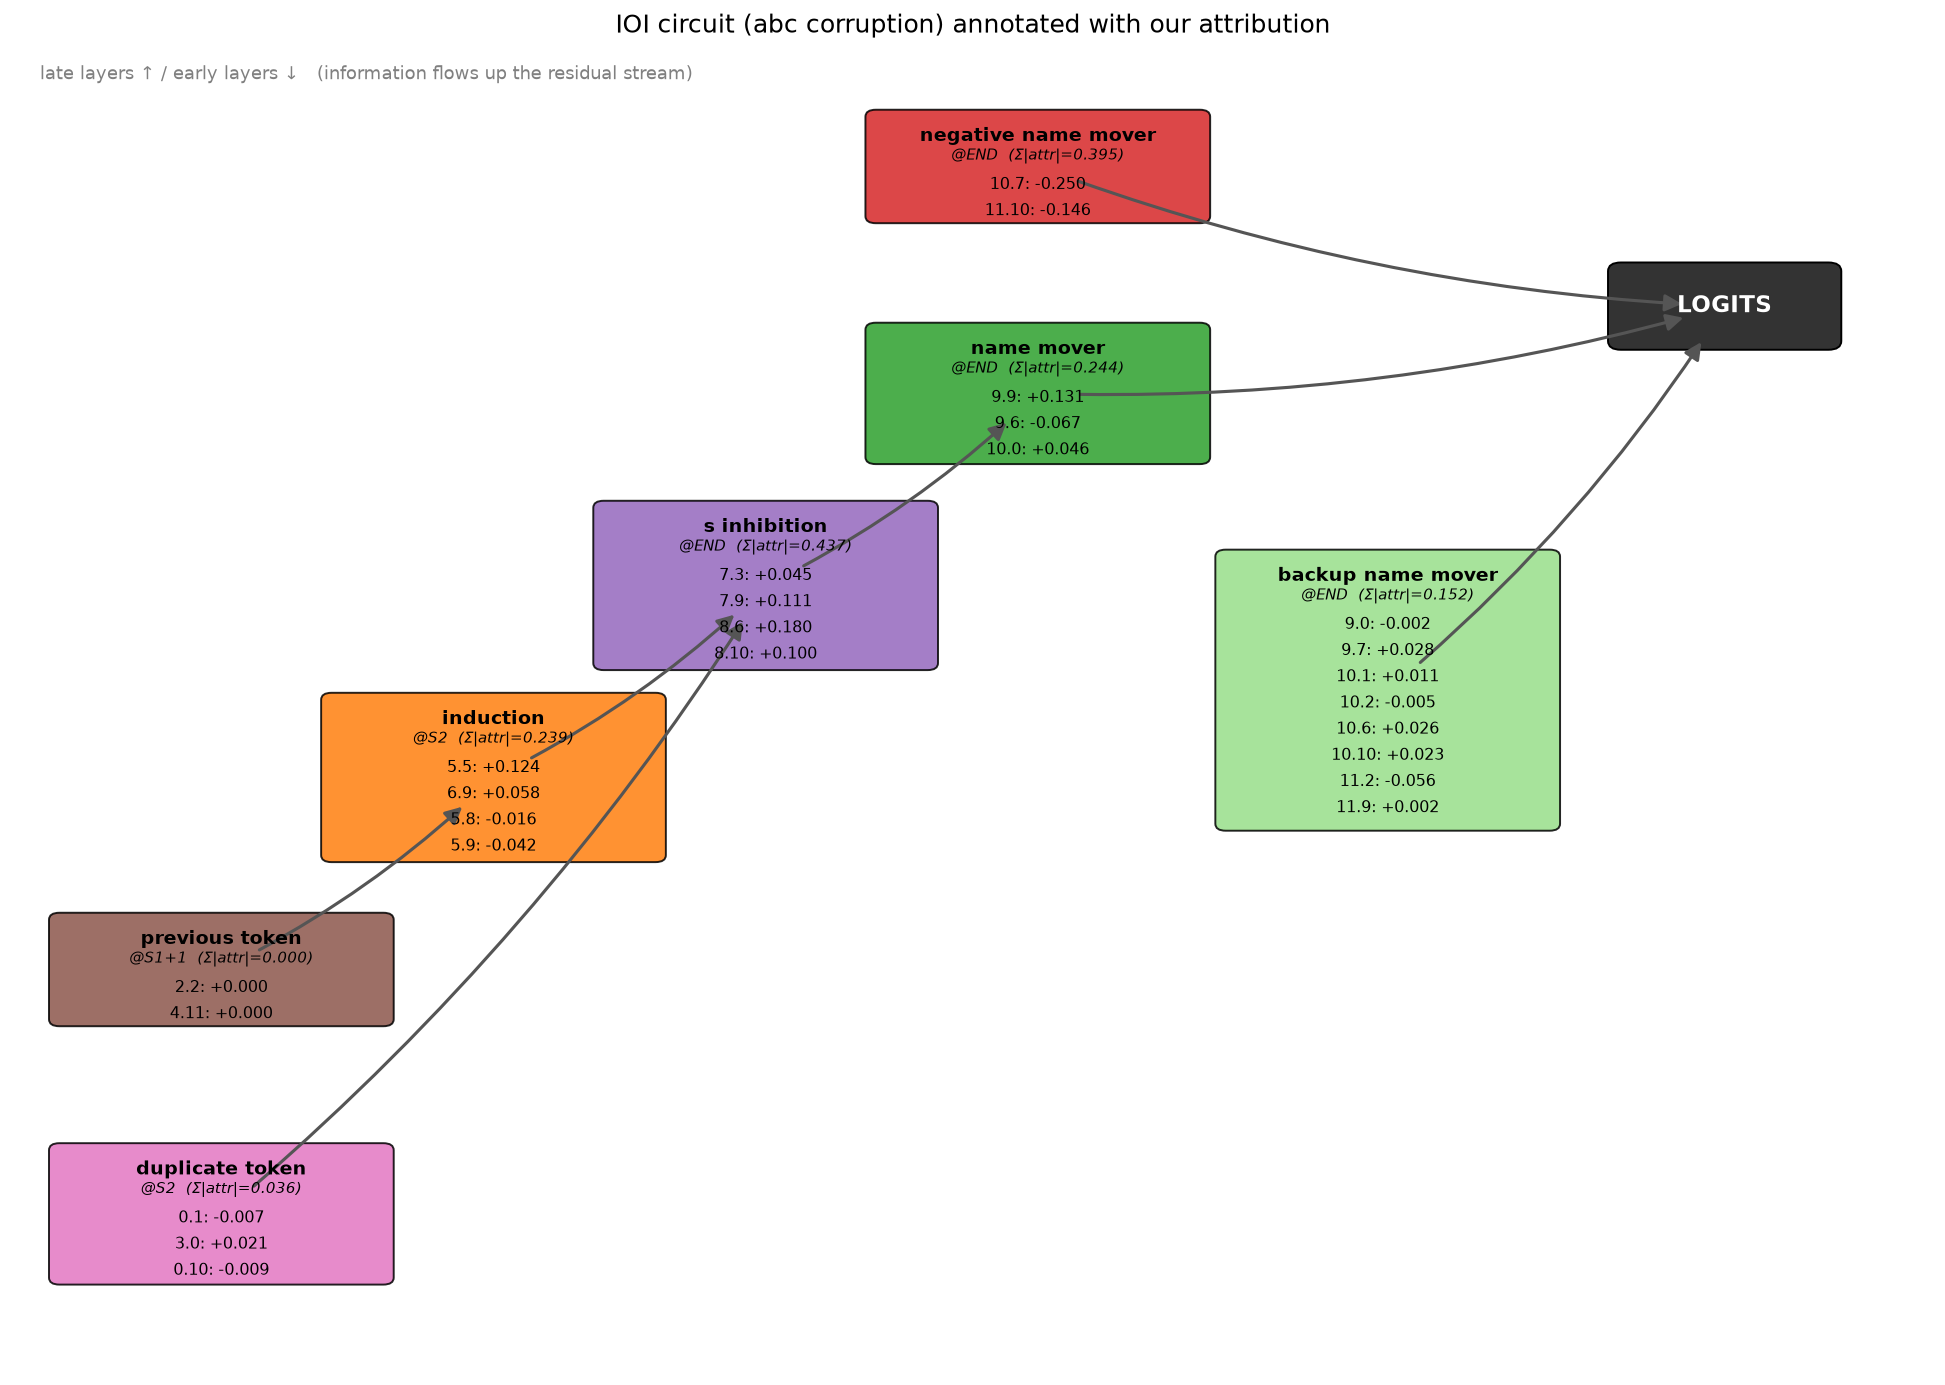

In [10]:
from src.circuit import CIRCUIT, CLASS_POSITION
pos_idx = {p: i for i, p in enumerate(res.pos_names)}
scores = {}
for cls, hs in CIRCUIT.items():
    for (l, h) in hs:
        scores[(l, h)] = res.head_by_pos[l, h, pos_idx[CLASS_POSITION[cls]]].item()
circuitdiagram.draw(scores, f'{FIGS}/nb_circuit.png',
                    title='IOI circuit (abc corruption) annotated with our attribution')
display(Image(f'{FIGS}/nb_circuit.png'))

### See also

- [`../docs/FINDINGS.md`](../docs/FINDINGS.md) — full writeup: recover the circuit, trace it, recreate the paper figures, and circuits **beyond** the paper.
- `run_circuit.py`, `run_counterfactuals.py`, `run_paper_figures.py`, `run_beyond.py` — the scaled-up runs.

## 7. Notes & storage

- Per-site `|attribution|` is large while the *signed* sum is small → heavy
  cancellation across dimensions/positions. Looking at all hidden dims (not
  aggregates) is what surfaces this.
- Attribution patching is a first-order **approximation** — great for ranking
  and whole-network maps; verify shortlisted nodes with exact activation
  patching before strong causal claims.
- The storage accounting (why this stays in MB, not GB) is in
  `../docs/STORAGE.md`.